In [147]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

### One-sample $t$-test

$$
T = \frac{(\bar{X} - \mu_0)}{s/\sqrt{n}}
$$

Under $H_0$, $T\sim t_{n-1}$.

When testing $H_0:\mu=\mu_0$ against the *two-sided alternative* $H_1:\mu\neq \mu_0$, we reject $H_0$ in favor of $H_1$ when $|T|\gg 0$.
The correspondig $p$-value is $P_{t\sim t_{n-1}}(t > |T|)$.

When testing $H_0:\mu=\mu_0$ against the *one-sided alternative* $H_1:\mu > \mu_0$, we reject $H_0$ in favor of $H_1$ when $T\gg 0$.
The correspondig $p$-value is $P_{t\sim t_{n-1}}(t > T)$.

When testing $H_0:\mu=\mu_0$ against the *one-sided alternative* $H_1:\mu < \mu_0$, we reject $H_0$ in favor of $H_1$ when $T\ll 0$.
The correspondig $p$-value is $P_{t\sim t_{n-1}}(t < T)$.


In [148]:
n = 10
mu0 = 1
x = stats.norm().rvs(size=n)

assert np.isclose(x.var(), np.sum((x - x.mean()) ** 2) / n)
assert np.isclose(x.var(ddof=1), np.sum((x - x.mean()) ** 2) / (n - 1))
assert np.isclose(x.std(), np.sqrt(np.sum((x - x.mean()) ** 2) / n))
assert np.isclose(x.std(ddof=1), np.sqrt(np.sum((x - x.mean()) ** 2) / (n - 1)))

result = stats.ttest_1samp(x, popmean=mu0)

assert np.isclose(result._estimate, x.mean())
assert np.isclose(result._standard_error, x.std(ddof=1) / np.sqrt(n))
assert result.df == n - 1
assert np.isclose(result.statistic, np.sqrt(n) * (x.mean() - mu0) / x.std(ddof=1))
assert np.isclose(result.pvalue, 2 * stats.t(df=result.df).sf(np.abs(result.statistic)))

result = stats.ttest_1samp(x, popmean=mu0, alternative="greater")

assert np.isclose(result._estimate, x.mean())
assert np.isclose(result._standard_error, x.std(ddof=1) / np.sqrt(n))
assert result.df == n - 1
assert np.isclose(result.statistic, np.sqrt(n) * (x.mean() - mu0) / x.std(ddof=1))
assert np.isclose(result.pvalue, stats.t(df=result.df).sf(result.statistic))

result = stats.ttest_1samp(x, popmean=mu0, alternative="less")

assert np.isclose(result._estimate, x.mean())
assert np.isclose(result._standard_error, x.std(ddof=1) / np.sqrt(n))
assert result.df == n - 1
assert np.isclose(result.statistic, np.sqrt(n) * (x.mean() - mu0) / x.std(ddof=1))
assert np.isclose(result.pvalue, stats.t(df=result.df).cdf(result.statistic))

### Confidence intervals

Define $t_{n-1, \alpha/2}$ by
$$
P_{T\sim t_{n-1}}(T > t_{n-1, \alpha/2}) = \alpha/2,
$$
so that
$$
P_{T\sim t_{n-1}}(|T| > t_{n-1, \alpha/2}) = \alpha.
$$

The $100(1 - \alpha)\%$-confidence interval for $\mu$ is
$$
\left[\bar{X} - t_{n-1, \alpha/2}\frac{s}{\sqrt{n}}, \bar{X} + t_{n-1, \alpha/2}\frac{s}{\sqrt{n}}\right].
$$

If $n\gg 0$, then we have the normal approximation $z_{\alpha/2}\approx t_{n-1, \alpha/2}$.

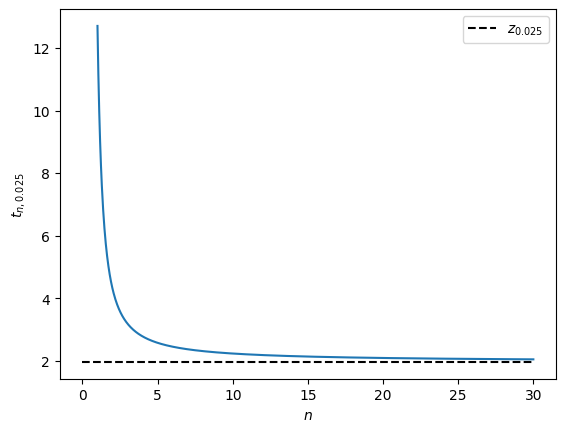

In [149]:
df = np.linspace(1, 30, 1000)
alpha = 0.05
t = stats.t(df=df).isf(alpha / 2)
z = stats.norm().isf(alpha / 2)
plt.plot(df, t)
plt.plot([0, 30], [z, z], "k--", label=f"$z_{{ {alpha/2} }}$")
plt.xlabel("$n$")
plt.ylabel(f"$t_{{n, {alpha/2} }}$")
plt.legend()
plt.show()

In [151]:
n = 10
mu = 1
sigma = 0.5
x = stats.norm(loc=mu, scale=sigma).rvs(size=n)
alpha = 0.05

result = stats.ttest_1samp(x, popmean=mu)
low, high = result.confidence_interval(confidence_level=1 - alpha)
t = stats.t(df=n - 1).isf(alpha / 2)
assert np.isclose(low, x.mean() - t * result._standard_error)
assert np.isclose(high, x.mean() + t * result._standard_error)
assert np.isclose(result._standard_error, x.std(ddof=1) / np.sqrt(n))
assert np.isclose(low, x.mean() - t * x.std(ddof=1) / np.sqrt(n))
assert np.isclose(high, x.mean() + t * x.std(ddof=1) / np.sqrt(n))

result = stats.ttest_1samp(x, popmean=mu, alternative="less")
low, high = result.confidence_interval(confidence_level=1 - alpha)
assert np.isclose(low, -np.inf)
t = stats.t(df=n - 1).isf(alpha)
assert np.isclose(high, x.mean() + t * x.std(ddof=1) / np.sqrt(n))

result = stats.ttest_1samp(x, popmean=mu, alternative="greater")
low, high = result.confidence_interval(confidence_level=1 - alpha)
assert np.isclose(high, np.inf)
t = stats.t(df=n - 1).isf(alpha)
assert np.isclose(low, x.mean() - t * x.std(ddof=1) / np.sqrt(n))

### Binomial test - buggy for $p\neq 0.5$!

In [ ]:
k = 5
n = 30
p = 0.5
result = stats.binomtest(k=k, n=n, p=p)
print(result)
assert np.isclose(result.statistic, k / n)
assert np.isclose(result.pvalue, 2 * stats.binom(n=n, p=p).cdf(k))

BinomTestResult(k=5, n=30, alternative='two-sided', statistic=0.16666666666666666, pvalue=0.0003249142318964005)


In [ ]:
k = 5
n = 30
p = 0.500001
result = stats.binomtest(k=k, n=n, p=p)
print(result)
assert np.isclose(result.statistic, k / n)
assert np.isclose(result.pvalue, 2 * stats.binom(n=n, p=p).cdf(k))

BinomTestResult(k=5, n=30, alternative='two-sided', statistic=0.16666666666666666, pvalue=0.00019218986847000717)


AssertionError: 

In [188]:
2 * stats.binom(n=n, p=p).cdf(k)

np.float64(0.0003249009602430815)

In [189]:
stats.chisquare?

Signature:
stats.chisquare(
    f_obs,
    f_exp=None,
    ddof=0,
    axis=0,
    *,
    sum_check=True,
    nan_policy='propagate',
    keepdims=False,
)
Docstring:
Perform Pearson's chi-squared test.

Pearson's chi-squared test [1]_ is a goodness-of-fit test for a multinomial
distribution with given probabilities; that is, it assesses the null hypothesis
that the observed frequencies (counts) are obtained by independent
sampling of *N* observations from a categorical distribution with given
expected frequencies.

Parameters
----------
f_obs : array_like
    Observed frequencies in each category.
f_exp : array_like, optional
    Expected frequencies in each category. By default, the categories are
    assumed to be equally likely.
ddof : int, optional
    "Delta degrees of freedom": adjustment to the degrees of freedom
    for the p-value.  The p-value is computed using a chi-squared
    distribution with ``k - 1 - ddof`` degrees of freedom, where ``k``
    is the number of categorie